In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math

# Affiche toutes les lignes
pd.set_option('display.max_rows', None)

# Affiche toutes les colonnes
pd.set_option('display.max_columns', None)
# Choisis le nombre de caractère par colonnes
pd.set_option('display.max_colwidth', 50)

In [144]:
from nltk import tokenize

In [145]:
def first_overview(df, name):
    print(f'Shape of {name} dataset : {df.shape}\n')
    print(f'Number of duplicate : {df.duplicated().sum()}\n')
    if df.shape[1] < 20:
        print(f'Variable types : \n{df.dtypes}\n')
    else:
        print(f'Variable types : \n{df.dtypes.value_counts()}\n')
    display(df.head(2))
    display(df.describe().T)
    try:
        display(df.describe(include=('object', 'str')).T)
    except:
        pass
    return 

In [146]:
def missing_val_overview(df, all_col=True):

    if all_col==True:
        info_col = df.columns
    else:
        info_col = df.columns[df.isna().any()]

    missing_table = pd.DataFrame({'Number': df[info_col].isna().sum(), 'Ratio': np.round(df[info_col].isna().sum()/df[info_col].shape[0]*100, 2)})
    missing_table = missing_table.sort_values(by='Ratio',ascending=False)
    print(f'Missing values : \n{missing_table}\n')
    
    plt.figure(figsize=(20, 5))
    sns.heatmap(df[info_col].isna(), cbar=False)
    plt.title('NaN values visualisation')
    plt.show()

In [147]:
def proportion_visualisation(df, num_col):
    # Number of columns and rows
    n = len(num_col)
    cols = 4
    rows = math.ceil(n / cols)
    # Main fig - size
    fig = plt.figure(figsize=(6*cols, 5*rows))
    # Sub fig - number
    outer = fig.add_gridspec(rows, cols)
    #
    for i, col in enumerate(num_col):
        # Fig location
        c = i % cols
        r = i // cols
        # Sub fig - parameters
        inner = outer[r, c].subgridspec(2, 1, height_ratios=[0.85, 0.15])
        # Add axis
        ax1 = fig.add_subplot(inner[0])
        ax2 = fig.add_subplot(inner[1])
        # first graph
        sns.histplot(df[col], ax=ax1)
        ax1.set_xlabel('')
        ax1.set_ylabel('Count')
        ax1.set_title(f'| {col} | - Histplot and Boxplot')
        # Second graph
        sns.boxplot(x=df[col], ax=ax2)
        ax2.set_xlabel('')
        ax2.set_ylabel('')
    #
    plt.tight_layout()
    plt.show()

In [148]:
def regplot_visualisation(df, num_col, target):
    
    # Number of columns and rows
    n = len(num_col)
    cols = 4
    rows = math.ceil(n / cols)

    # Main fig - size
    fig = plt.figure(figsize=(6*cols, 5*rows))

    # Sub fig - number
    outer = fig.add_gridspec(rows, cols)

    for i, col in enumerate(num_col):

        # Fig location
        c = i % cols
        r = i // cols

        # Sub fig - parameters
        inner = outer[r, c].subgridspec(2, 1, height_ratios=[0.85, 0.15])

        # Add axis
        ax1 = fig.add_subplot(inner[0])
        ax2 = fig.add_subplot(inner[1])

        # First graph : regplot with target
        sns.regplot(data=df, x=col, y=target, ax=ax1, scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})
        ax1.set_xlabel('')
        ax1.set_ylabel(target)
        ax1.set_title(f'| {col} | - Regplot with {target}')

        # Second graph : histogram
        sns.histplot(df[col], ax=ax2)
        ax2.set_xlabel(col)
        ax2.set_ylabel('')

    plt.tight_layout()
    plt.show()

In [149]:
data_path = 'washington_ultimate.csv'

data_raw = pd.read_csv(data_path)

In [150]:
df = data_raw.copy()

In [151]:
first_overview(df, 'Washington real estate')

Shape of Washington real estate dataset : (12017, 15)

Number of duplicate : 0

Variable types : 
zip                   float64
type                      str
year_built            float64
listPrice             float64
lastSoldPrice         float64
list_to_sold_ratio    float64
sqft                  float64
price_per_sqft        float64
stories               float64
beds                  float64
baths                 float64
baths_full            float64
baths_full_calc       float64
garage                float64
sanitized_text            str
dtype: object



,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text
0,99156.0,single_family,1997.0,875054.0,875085.0,1.000,2710.0,322.91,1.0,3.0,3.0,2.0,2.0,3.0,"2, 700+ sq ft residence features 3 beds, 2.5 b..."
1,99006.0,single_family,1900.0,349989.0,347902.0,0.994,1460.0,238.29,2.0,3.0,2.0,2.0,2.0,NaN,"this beautifully remodeled 3-bedroom, 2-bath h..."


,count,mean,std,min,25%,50%,75%,max
zip,12014.0,98470.878059,396.832853,98001.0000,98122.0000,98371.0,98665.0000,9.940300e+04
year_built,11157.0,1985.959129,32.268603,1875.0000,1967.0000,1992.0,2013.0000,2.026000e+03
listPrice,10325.0,701848.628184,550703.149523,1000.0000,405062.0000,569974.0,800081.0000,1.090007e+07
lastSoldPrice,12002.0,729124.509915,707800.246765,1000.0000,400028.7500,568006.0,824912.0000,1.575121e+07
list_to_sold_ratio,10310.0,0.991343,0.062016,0.0028,0.9783,1.0,1.0004,2.224900e+00
sqft,11145.0,2007.775684,1113.447253,120.0000,1340.0000,1810.0,2440.0000,2.968000e+04
price_per_sqft,11121.0,367.886257,189.541242,0.6500,251.3900,324.3,440.6600,1.988730e+03
stories,10506.0,1.561965,0.775282,0.0000,1.0000,2.0,2.0000,3.100000e+01
beds,11085.0,3.262517,1.112333,0.0000,3.0000,3.0,4.0000,1.800000e+01
baths,11533.0,2.363565,1.151564,0.0000,2.0000,2.0,3.0000,2.000000e+01


,count,unique,top,freq
type,12017,9,single_family,8840
sanitized_text,10298,10133,the foyer is open to spacious great room with ...,8


Missing values : 
                    Number  Ratio
garage                9654  80.34
sanitized_text        1719  14.30
list_to_sold_ratio    1707  14.20
listPrice             1692  14.08
stories               1511  12.57
baths_full            1249  10.39
baths_full_calc       1013   8.43
beds                   932   7.76
price_per_sqft         896   7.46
sqft                   872   7.26
year_built             860   7.16
baths                  484   4.03
lastSoldPrice           15   0.12
zip                      3   0.02
type                     0   0.00



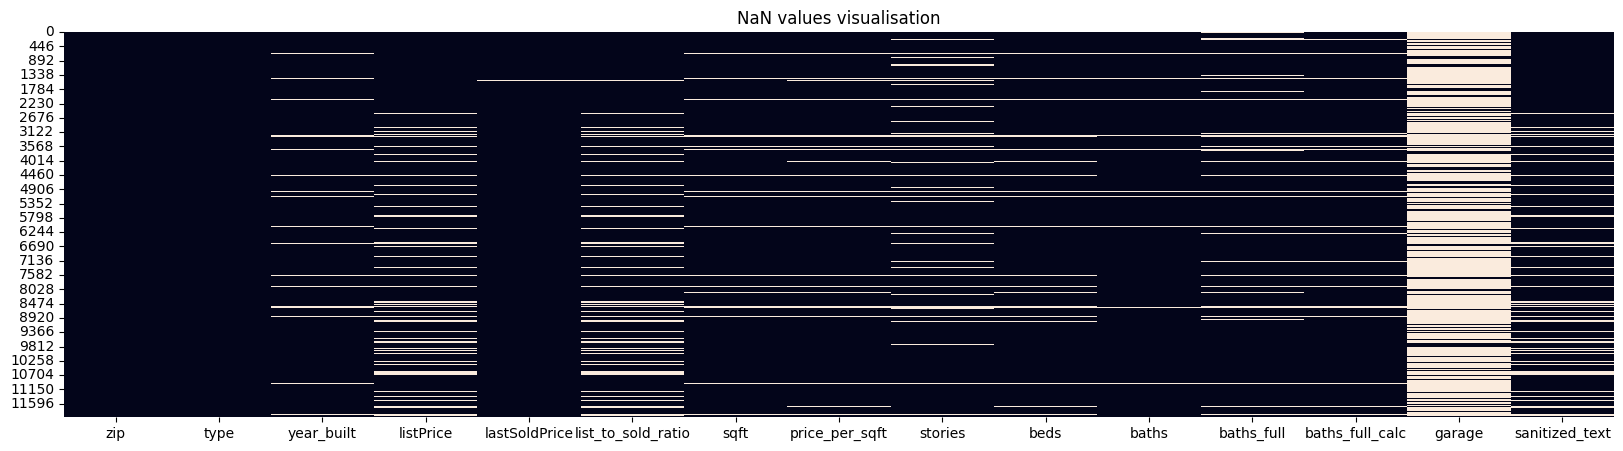

In [152]:
missing_val_overview(df)

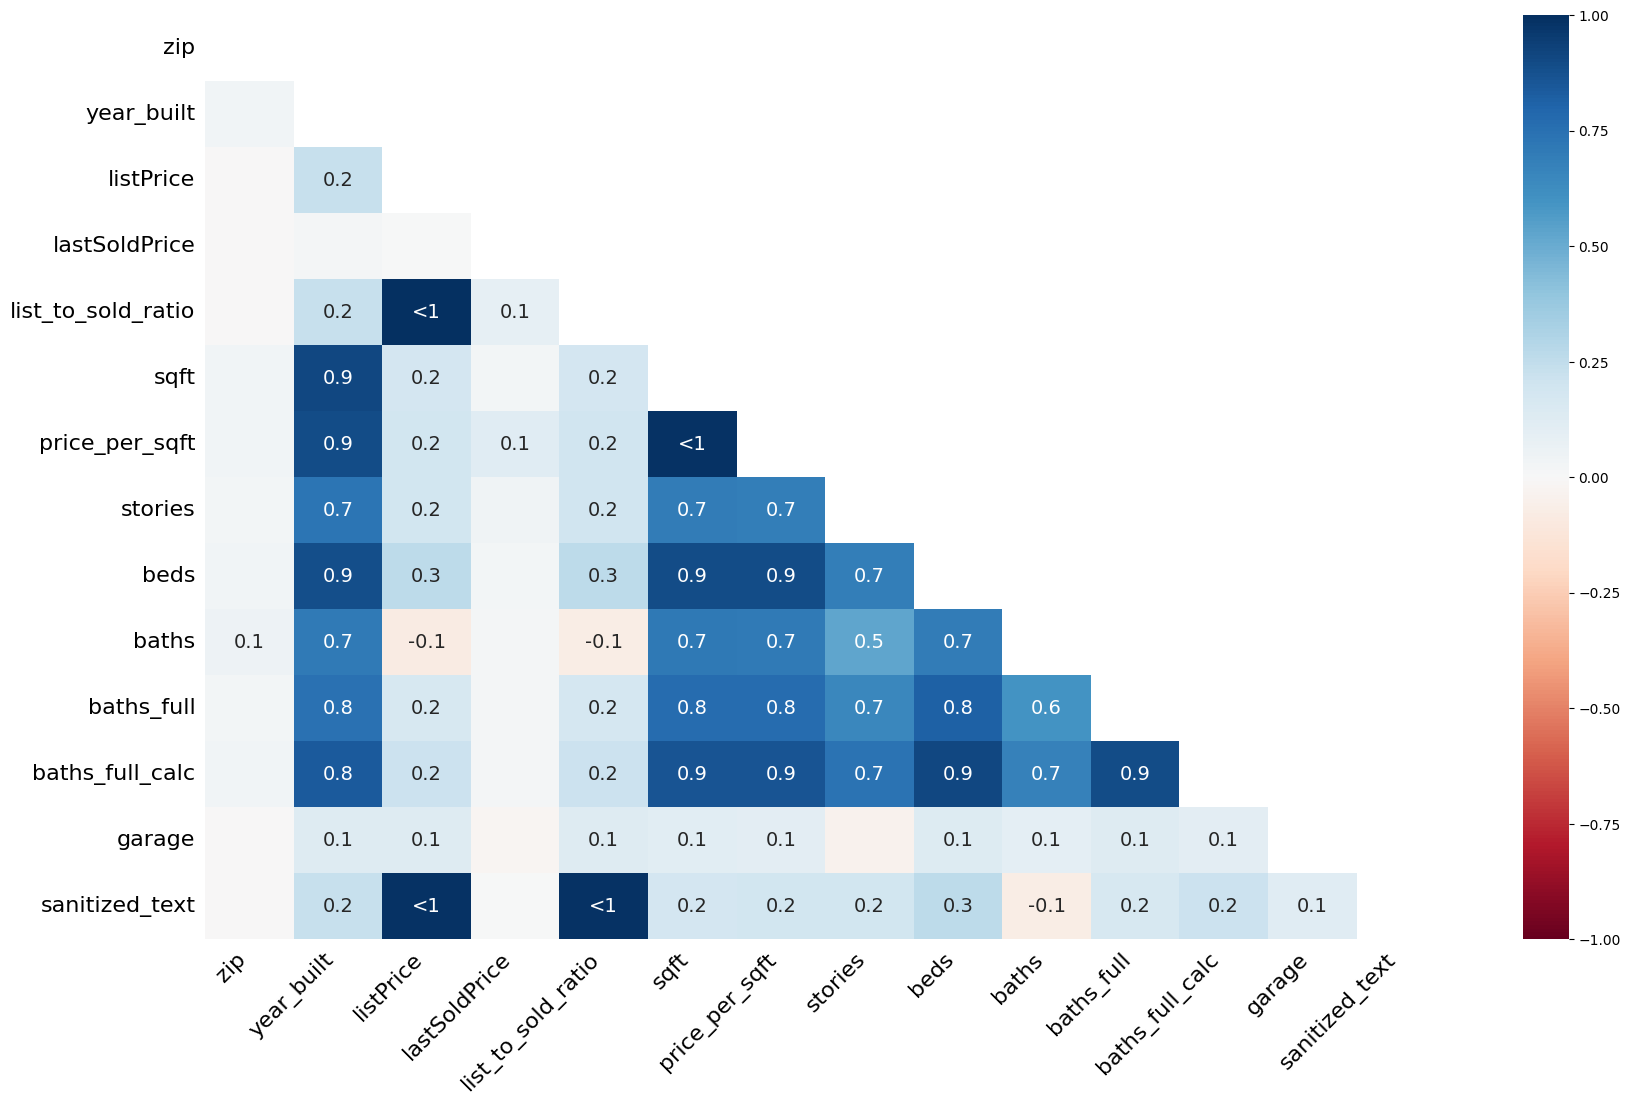

In [153]:
msno.heatmap(df)
plt.show()

# Ajout variable de localisation

https://simplemaps.com/us-zips/WA/

In [154]:
loc_data = pd.read_csv('uszips.csv')

In [155]:
loc_data.head(2)

,zip,lat,lng,city,state_id,state_name,zcta,parent_zcta,population,density,county_fips,county_name,county_weights,county_names_all,county_fips_all,imprecise,military,timezone
0,601,18.18027,-66.75266,Adjuntas,PR,Puerto Rico,True,NaN,16669.0,99.9,72001,Adjuntas,"{""72001"": 98.74, ""72141"": 1.26}",Adjuntas|Utuado,72001|72141,False,False,America/Puerto_Rico
1,602,18.36075,-67.17541,Aguada,PR,Puerto Rico,True,NaN,37233.0,474.0,72003,Aguada,"{""72003"": 100}",Aguada,72003,False,False,America/Puerto_Rico


In [156]:
loc_data = loc_data[['zip', 'population']]

In [157]:
df = pd.merge(
    df, 
    loc_data, 
    on='zip', 
    how='left', 
)

In [158]:
def cat_zip(row):
    zip_code = str(row['zip'])
    #
    #  Mégalopole urbaine et technologique
    if zip_code.startswith(('980', '981', '982')):
        return 'puget_sound_core'
    # Zones portuaires, capitale d'état, et côte Pacifique
    elif zip_code.startswith(('983', '985', '986')):
        return 'south_and_coast'
    # Vallées agricoles et viticoles
    elif zip_code.startswith(('988', '989')):
        return 'central_valleys'
    # Seconde métropole de l'état
    elif zip_code.startswith(('990', '992', '993')):
        return 'spokane_inland_empire'
    # Autres zones peu peuplées
    elif zip_code.startswith(('98', '99')) :
        return 'other'

In [159]:
df['group_zip'] = df.apply(cat_zip, axis=1)

# DDD

In [160]:
num_col = list(df.select_dtypes(include=['int', 'float']).columns)

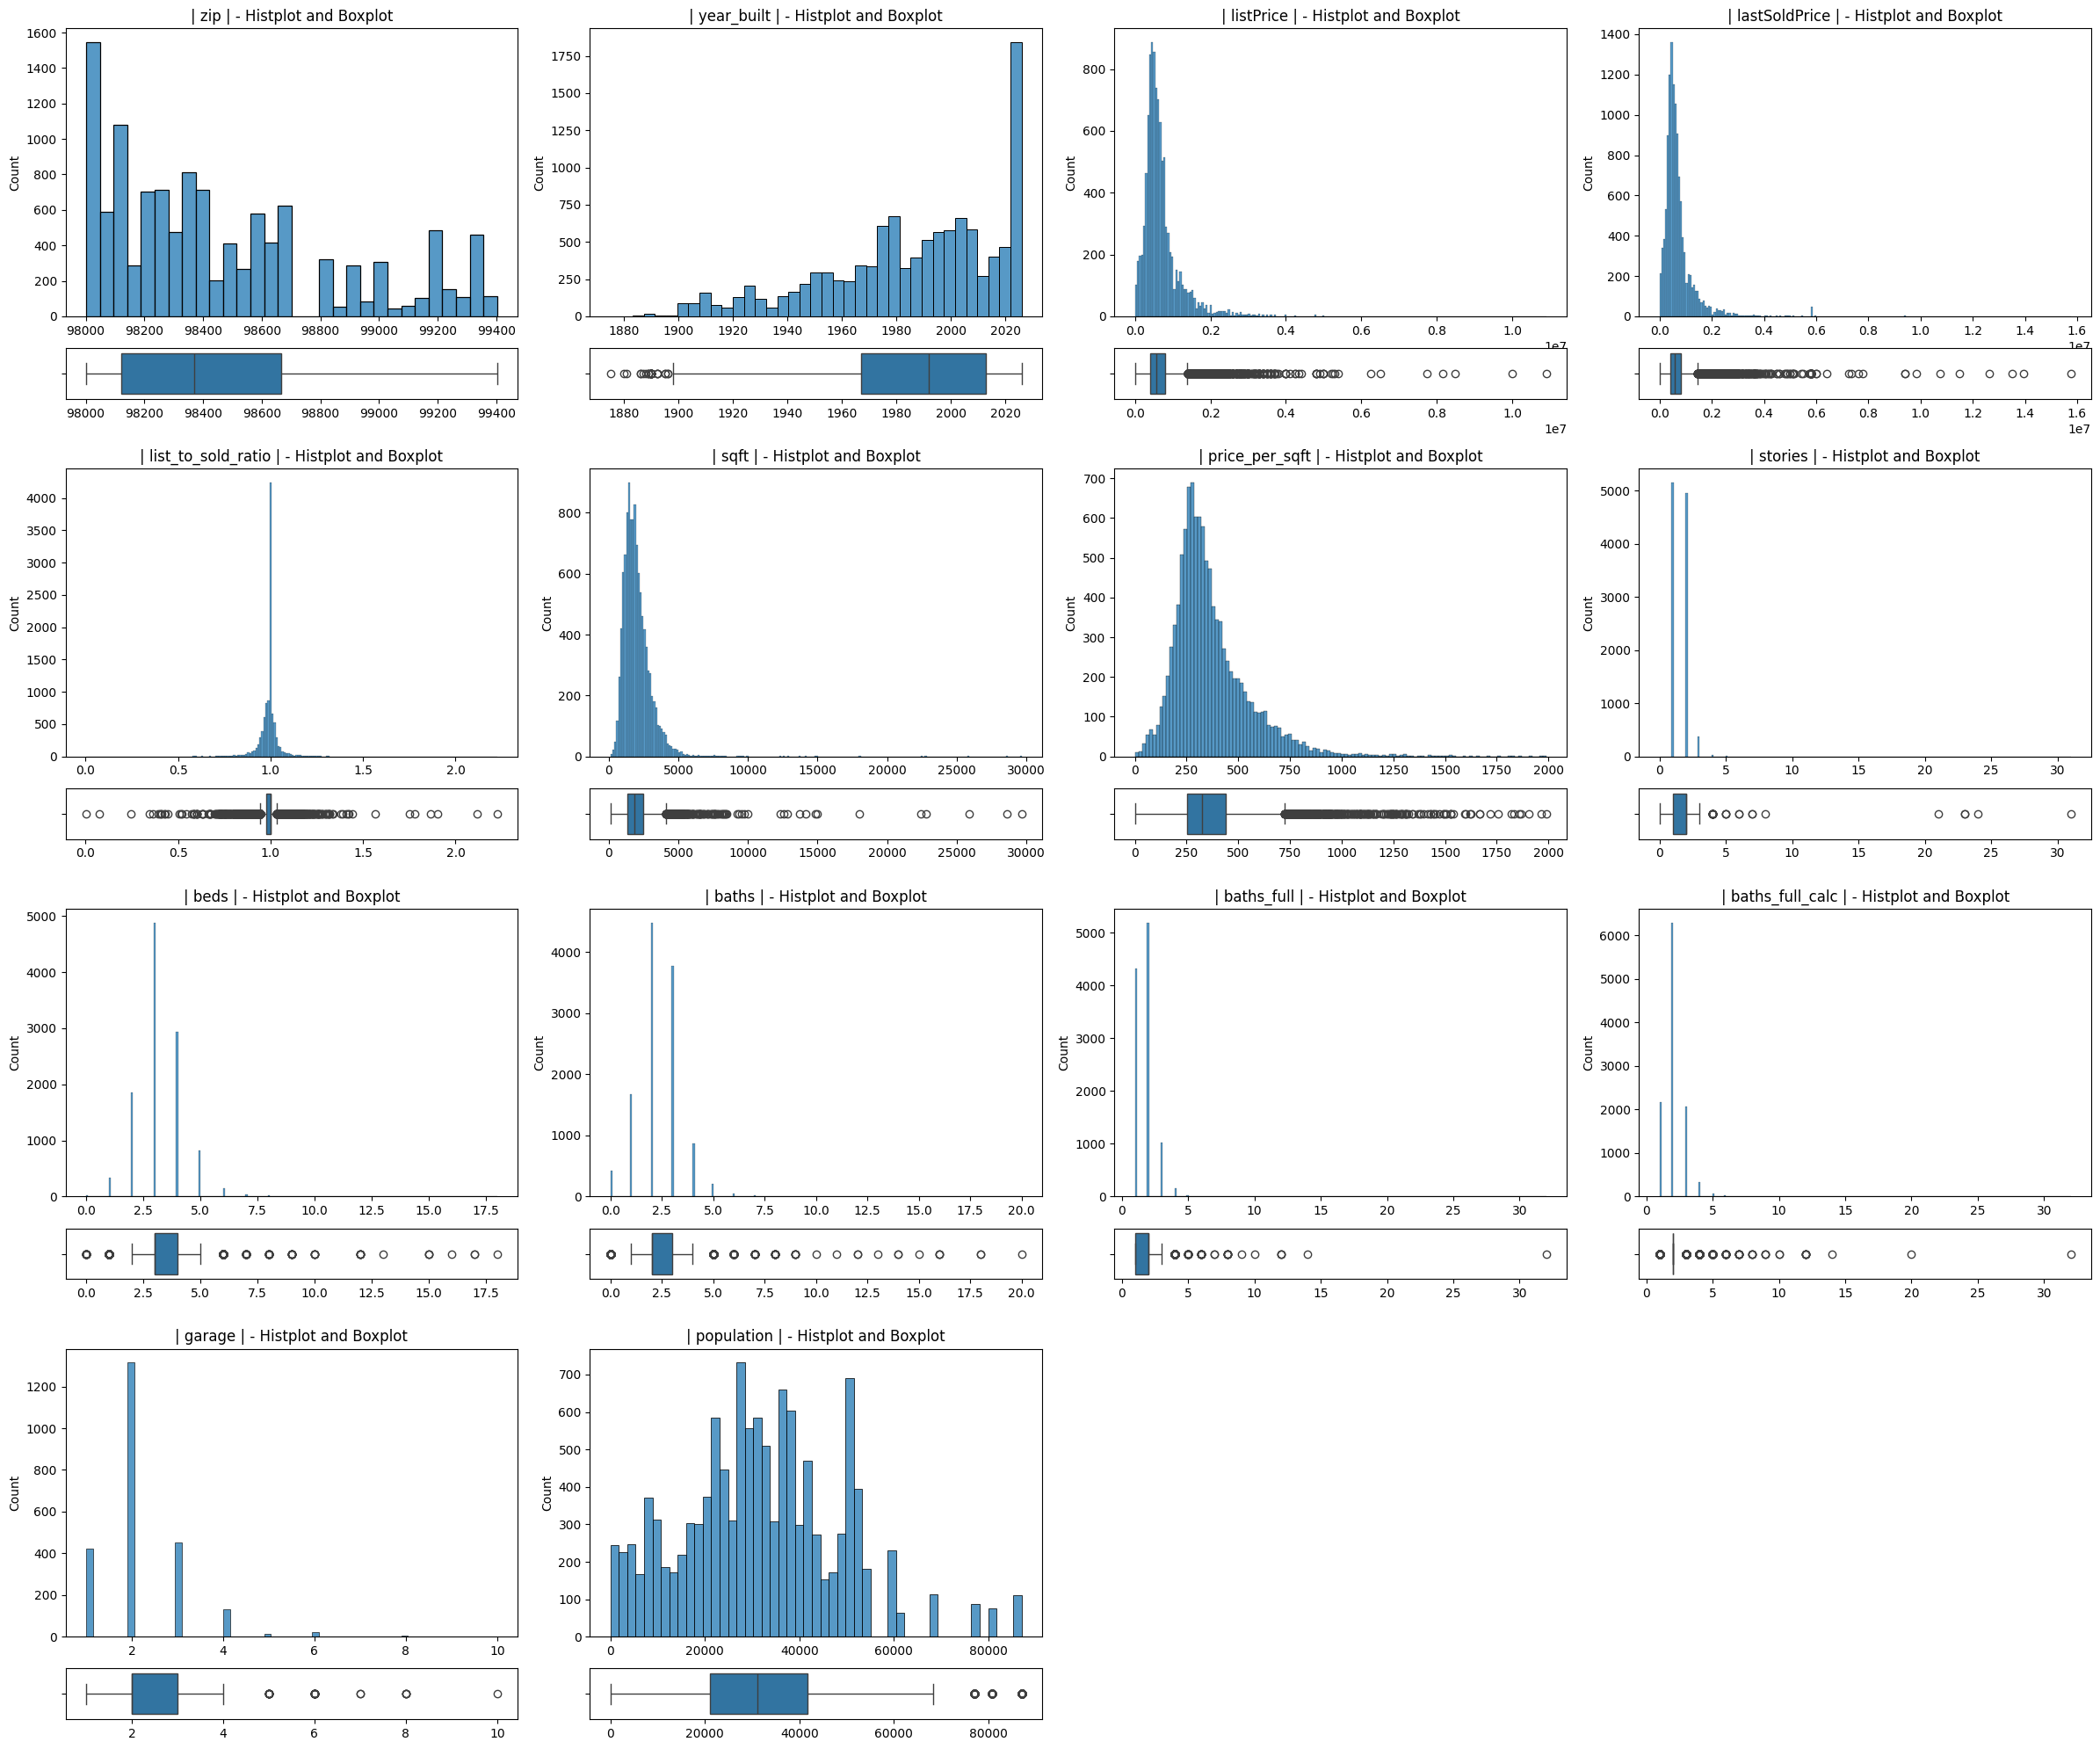

In [161]:
proportion_visualisation(df, num_col)

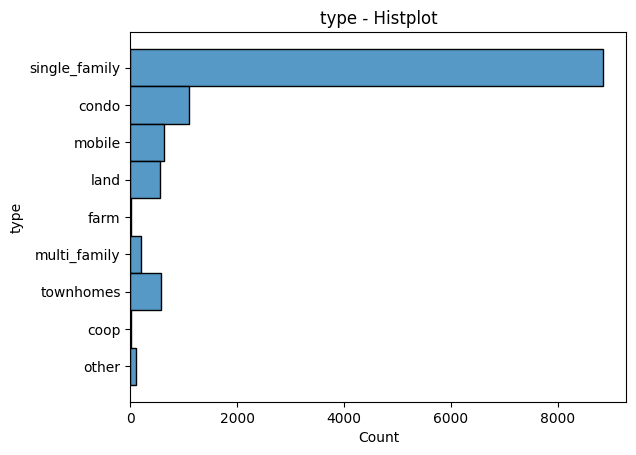

In [162]:
sns.histplot(y=df['type'])
plt.title(f'type - Histplot')
plt.show()

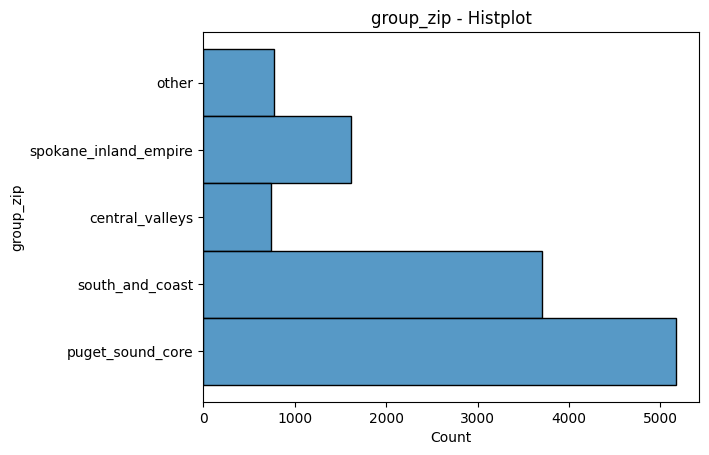

In [163]:
sns.histplot(y=df['group_zip'])
plt.title(f'group_zip - Histplot')
plt.show()

# zip / group_zip / population

Il n'y a que 3 à 5 NaN.   
Pas de similitude.   
On peut faire le choix de les supprimer ou de les remplacer par le mode.

In [164]:
df['zip'].nunique()

475

In [165]:
df.loc[df['zip'].isna()]

,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text,population,group_zip
1011,NaN,land,NaN,425236.0,412067.0,0.9690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,retail lots at the fast growing intersection o...,NaN,NaN
2461,NaN,single_family,2015.0,1350060.0,1349920.0,0.9999,3250.0,415.36,2.0,6.0,4.0,3.0,4.0,2.0,this home is located in the heart of Kenmore. ...,NaN,NaN
10021,NaN,land,NaN,95096.0,94907.0,0.9980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,this is your rare opportunity to purchase a la...,NaN,NaN


In [166]:
df.loc[df['group_zip'].isna()]

,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text,population,group_zip
1011,NaN,land,NaN,425236.0,412067.0,0.9690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,retail lots at the fast growing intersection o...,NaN,NaN
2461,NaN,single_family,2015.0,1350060.0,1349920.0,0.9999,3250.0,415.36,2.0,6.0,4.0,3.0,4.0,2.0,this home is located in the heart of Kenmore. ...,NaN,NaN
10021,NaN,land,NaN,95096.0,94907.0,0.9980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,this is your rare opportunity to purchase a la...,NaN,NaN


Les 2 valeurs de population viennent de Everett, WA

In [167]:
df.loc[df['population'].isna()]

,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text,population,group_zip
1011,NaN,land,NaN,425236.0,412067.0,0.9690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,retail lots at the fast growing intersection o...,NaN,NaN
2461,NaN,single_family,2015.0,1350060.0,1349920.0,0.9999,3250.0,415.36,2.0,6.0,4.0,3.0,4.0,2.0,this home is located in the heart of Kenmore. ...,NaN,NaN
2913,98206.0,single_family,1966.0,455061.0,427576.0,0.9396,830.0,515.15,1.0,2.0,1.0,1.0,1.0,NaN,"private marina, sandy beaches, USGA golf cours...",NaN,puget_sound_core
10021,NaN,land,NaN,95096.0,94907.0,0.9980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,this is your rare opportunity to purchase a la...,NaN,NaN
11594,98206.0,single_family,1967.0,440092.0,440073.0,1.0000,900.0,488.97,1.0,1.0,1.0,NaN,1.0,NaN,private island bluff cabin w/ views of Puget S...,NaN,puget_sound_core


# "year_built"

Pas de similitude entre les NaN (remplacer par la médiane).   
- Code zip vaste : 293 valeurs uniques et  par de valeur unique / très majoritaire
- Pas de densité unique / très majoritaire
- Tout type de propriété

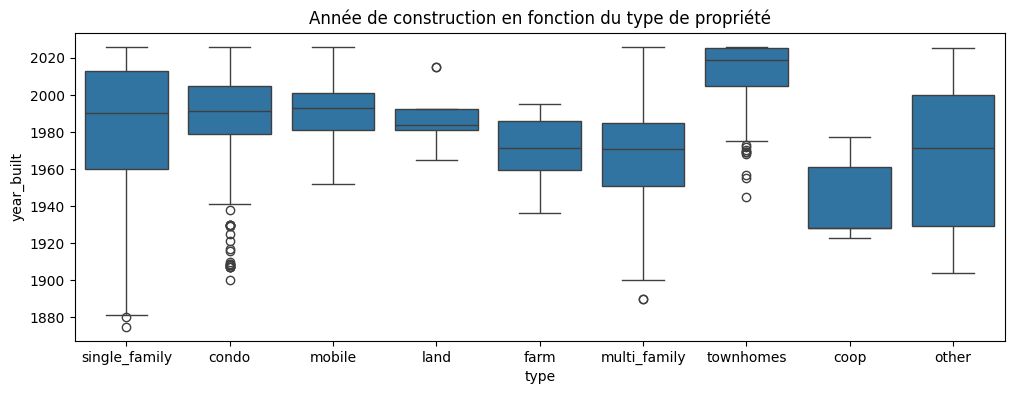

In [168]:
# Année de construction par rapport au type de propriété
plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='type', y='year_built')
plt.title('Année de construction en fonction du type de propriété')
plt.show()

In [169]:
print(f'Nombre de zip unique (year_built = NaN) : {df["zip"].loc[df["year_built"].isna()].nunique()}')

Nombre de zip unique (year_built = NaN) : 293


In [170]:
print('Pourcentage de propriété sans année de construction en fonction de la localisation :')
print()
print(df["group_zip"].loc[df['year_built'].isna()].value_counts().head(10) / df['year_built'].isna().sum() * 100)
print('\n10 plus grandes valeurs :')
print(df['zip'].loc[df['year_built'].isna()].value_counts().head(10) / df['year_built'].isna().sum() * 100)

Pourcentage de propriété sans année de construction en fonction de la localisation :

group_zip
south_and_coast          34.069767
puget_sound_core         33.837209
spokane_inland_empire    13.139535
central_valleys          12.441860
other                     6.279070
Name: count, dtype: float64

10 plus grandes valeurs :
zip
98229.0    6.279070
98382.0    1.627907
98816.0    1.627907
99006.0    1.627907
98640.0    1.627907
98042.0    1.627907
98569.0    1.511628
98584.0    1.395349
98230.0    1.279070
99352.0    1.279070
Name: count, dtype: float64


<Axes: xlabel='population', ylabel='Count'>

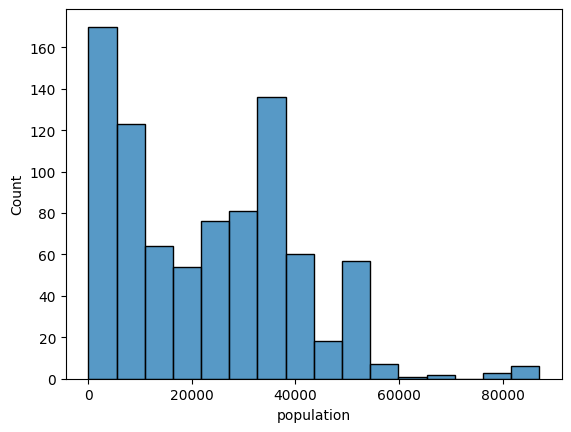

In [171]:
sns.histplot(df.loc[df['year_built'].isna(), 'population']) 

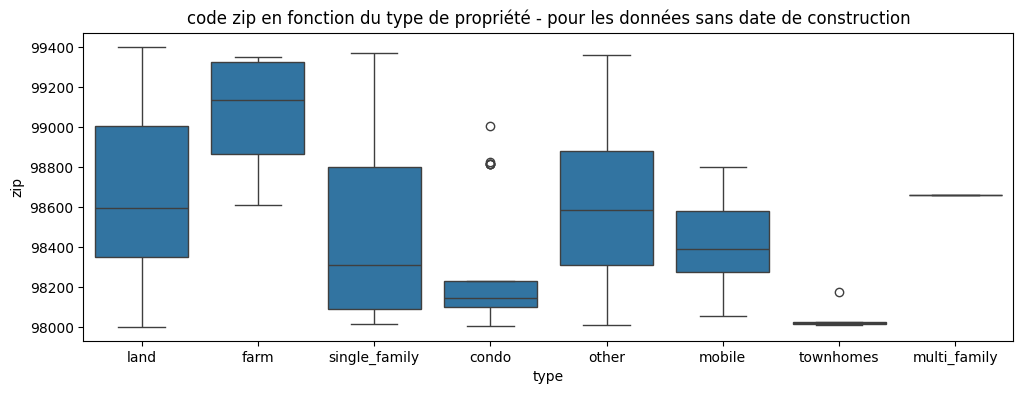

In [172]:
# Année de construction par rapport au type de propriété
plt.figure(figsize=(12,4))
sns.boxplot(data=df.loc[df['year_built'].isna()], x='type', y='zip')
plt.title('code zip en fonction du type de propriété - pour les données sans date de construction')
plt.show()

In [173]:
df[df['type'] == 'multi_family'].loc[df['year_built'].isna()]

,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text,population,group_zip
7695,98661.0,multi_family,NaN,NaN,3650050.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,50743.0,south_and_coast
7712,98661.0,multi_family,NaN,NaN,3649932.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,50743.0,south_and_coast
7715,98661.0,multi_family,NaN,NaN,3650092.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,50743.0,south_and_coast
7734,98661.0,multi_family,NaN,NaN,3650062.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,50743.0,south_and_coast


# "listPrice"

Pas de similitude.    
Utilisation médiane.

In [174]:
df.loc[df['listPrice'].isna()].head(20)

,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text,population,group_zip
1646,98685.0,single_family,2004.0,NaN,720054.0,NaN,2480.0,290.34,2.0,4.0,3.0,3.0,3.0,4.0,NaN,30607.0,south_and_coast
1894,98258.0,single_family,2016.0,NaN,722561.0,NaN,3190.0,226.51,2.0,5.0,5.0,4.0,4.0,NaN,NaN,52752.0,puget_sound_core
1910,98664.0,single_family,1970.0,NaN,409935.0,NaN,1040.0,394.17,1.0,3.0,2.0,2.0,2.0,NaN,NaN,23845.0,south_and_coast
1918,98290.0,single_family,1993.0,NaN,472103.0,NaN,1620.0,291.42,1.0,NaN,2.0,2.0,2.0,NaN,NaN,39826.0,puget_sound_core
1919,98682.0,single_family,1991.0,NaN,319910.0,NaN,1240.0,257.99,1.0,3.0,2.0,2.0,2.0,NaN,NaN,68305.0,south_and_coast
1939,98292.0,single_family,1993.0,NaN,849950.0,NaN,2170.0,391.68,1.0,3.0,2.0,2.0,2.0,NaN,NaN,27389.0,puget_sound_core
1951,98629.0,single_family,2005.0,NaN,829090.0,NaN,2770.0,299.31,1.0,4.0,3.0,2.0,2.0,NaN,NaN,9076.0,south_and_coast
2172,98208.0,single_family,1978.0,NaN,740068.0,NaN,2090.0,354.10,2.0,4.0,3.0,2.0,2.0,NaN,NaN,60915.0,puget_sound_core
2345,98801.0,single_family,1987.0,NaN,584937.0,NaN,2030.0,288.15,2.0,3.0,2.0,2.0,2.0,NaN,NaN,45426.0,central_valleys
2368,99352.0,single_family,1952.0,NaN,349923.0,NaN,1480.0,236.43,1.0,3.0,1.0,1.0,1.0,NaN,NaN,37430.0,spokane_inland_empire


In [175]:
df['type'].loc[df['listPrice'].isna()].value_counts()

type
single_family    1111
condo             244
other             111
mobile             86
land               55
townhomes          51
multi_family       34
Name: count, dtype: int64

# "stories"

Pour "lands", stories = 0   
Pour les autres, utilisation de leurs médianes    
Pour "coop", pas de valeur pour stories ce qui pourrait être :
- Pas d'étage donc abscence à l'incrémentation donc = 0
- Erreur d'incrémentation (sur 5 valeurs ce qui est possible) donc on prend la médiane d'un type proche --> "condo" (tous les deux des copropriétés)    

Type de propriété quand stories = NaN :
type
land             549
single_family    493
condo            152
multi_family     135
other             83
mobile            82
townhomes          8
coop               5
farm               4
Name: count, dtype: int64



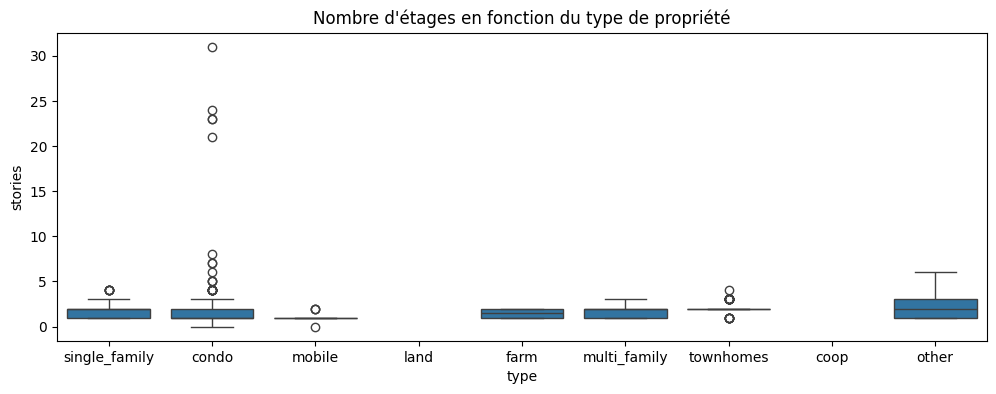

In [176]:
# Type de propriété quand stories = NaN
print('Type de propriété quand stories = NaN :')
print(f'{df.loc[df["stories"].isna(), "type"].value_counts()}\n')

# Nombre d'étages par rapport au type de propriété
plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='type', y='stories')
plt.title("Nombre d'étages en fonction du type de propriété")
plt.show()

# "beds"

Pour "lands", stories = 0   
Pour les autres, utilisation de leurs médianes 

Type de propriété quand stories = NaN :
type
land             549
single_family    140
other            103
condo             77
mobile            32
multi_family      23
farm               4
townhomes          4
Name: count, dtype: int64



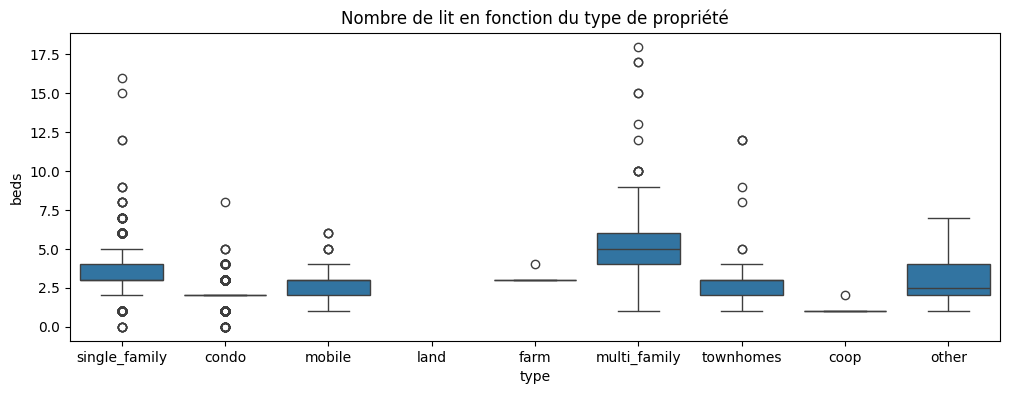

In [177]:
# Type de propriété quand beds = NaN
print('Type de propriété quand stories = NaN :')
print(f'{df.loc[df["beds"].isna(), "type"].value_counts()}\n')

# Nombre de lit par rapport au type de propriété
plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='type', y='beds')
plt.title("Nombre de lit en fonction du type de propriété")
plt.show()

# "garage"

Même reflexion qu'avec "stories"

Type de propriété quand stories = NaN :
type
single_family    6830
condo             966
mobile            556
land              549
townhomes         508
multi_family      125
other             105
farm               10
coop                5
Name: count, dtype: int64



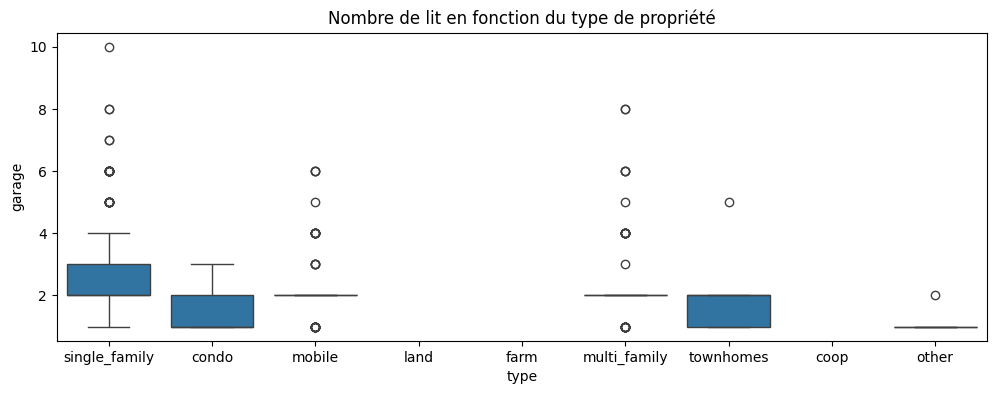

In [178]:
# Type de propriété quand beds = NaN
print('Type de propriété quand stories = NaN :')
print(f'{df.loc[df["garage"].isna(), "type"].value_counts()}\n')

# Nombre de lit par rapport au type de propriété
plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='type', y='garage')
plt.title("Nombre de lit en fonction du type de propriété")
plt.show()

# baths / baths_full / baths_full_calc

D'après les normes américaines, "baths" devrait toujours être supérieur ou égal à "baths_full" (baths = full bath + three-quarter bath + half bath + quarter bath).    
Plusieurs propriétés ont des valeurs érronées.    
On peut voir que cette erreur est encore plus présente dans la version calculé (baths_full_calc).

In [179]:
(df['baths'] - df['baths_full']).value_counts().sort_index()

-3.0        2
-2.0        1
-1.0       37
 0.0     4880
 1.0     4297
 2.0     1314
 3.0      199
 4.0       19
 5.0        8
 6.0        4
 8.0        3
 9.0        1
 10.0       1
 11.0       1
Name: count, dtype: int64

In [180]:
(df['baths'] - df['baths_full_calc']).value_counts().sort_index()

-3.0        3
-2.0        3
-1.0       61
 0.0     7252
 1.0     3540
 2.0      130
 3.0        7
 4.0        3
 6.0        2
 8.0        1
 11.0       1
Name: count, dtype: int64

In [181]:
(df['baths_full'] - df['baths_full_calc']).value_counts().sort_index()

-8.0       1
-4.0       8
-3.0      38
-2.0     463
-1.0    2858
 0.0    7400
Name: count, dtype: int64

La majorité des NaN viennent de terrain ("land").    
C'est terrain n'ont pas de salle de bain --> "baths" = 0


type
land             467
multi_family       6
farm               4
condo              4
single_family      2
mobile             1
Name: count, dtype: int64


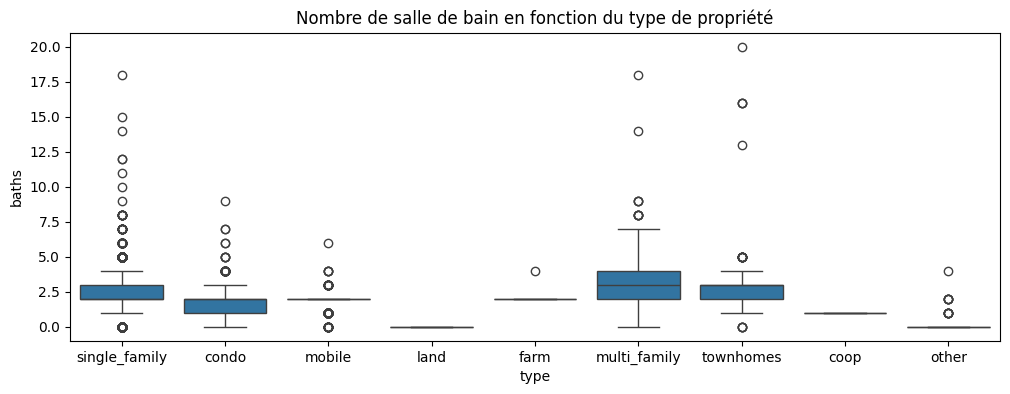

In [182]:
# Type de propriété quand bath = NaN
print(f'\n{df.loc[df["baths"].isna(), "type"].value_counts()}')

# Nombre de salle de bain par rapport au type de propriété
plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='type', y='baths')
plt.title('Nombre de salle de bain en fonction du type de propriété')
plt.show()

In [183]:
print(df.loc[(df['type'] == "land"), 'baths'].value_counts())

baths
0.0    82
Name: count, dtype: int64


Quand "bath_full" ou "bath_full_calc" = NaN, "baths" est toujours un entier.   
- Que des half bath, ... ?    
- Erreur dans l'incrémentation des valeurs ?

In [184]:
# Nombre de salle de bain quand bath_full = NaN
print(f'\n{df.loc[df["baths_full"].isna(), "baths"].value_counts()}')


baths
0.0     419
1.0     123
2.0     122
3.0      46
4.0      38
6.0       5
5.0       5
8.0       4
9.0       2
18.0      1
7.0       1
Name: count, dtype: int64


In [185]:
# Nombre de salle de bain quand bath_full_calc = NaN
print(f'\n{df.loc[df["baths_full_calc"].isna(), "baths"].value_counts()}')


baths
0.0     419
2.0      40
4.0      33
1.0      11
3.0      10
6.0       5
8.0       4
5.0       4
9.0       2
18.0      1
7.0       1
Name: count, dtype: int64


# Remplacement des erreurs d'incrémentations

In [186]:
col_to_fill = ['stories', 'beds', 'garage', 'baths', 'baths_full', 'baths_full_calc']
df.loc[(df['type'] == 'land'), col_to_fill] = df.loc[(df['type'] == 'land'), col_to_fill].fillna(0)

# Proportion des NaN
Lignes avec 10 ou plus NaN. On pourrait se poser la question si on doit les garder ou mettre un seuil.

In [187]:
# Compter le nombre de NaN par ligne
nan_counts = df.isna().sum(axis=1)

# Compter la fréquence de chaque nombre de NaN (de 0 à 15)
# value_counts() retourne seulement les valeurs présentes, on réindexe pour avoir tout de 0 à 15
distrib_nan = nan_counts.value_counts().sort_index()

print(distrib_nan)

0     1847
1     7457
2      373
3      655
4     1095
5      108
6      134
7       44
8       30
9       21
10      10
11     242
12       1
Name: count, dtype: int64


# Variables / "lastSoldPrice"
"list_to_sold_ratio" et "price_per_sqft" sont calculés via "lastSoldPrice" donc on ne va pas les utiliser

In [188]:
reg_col = ['zip', 'year_built', 'listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage']

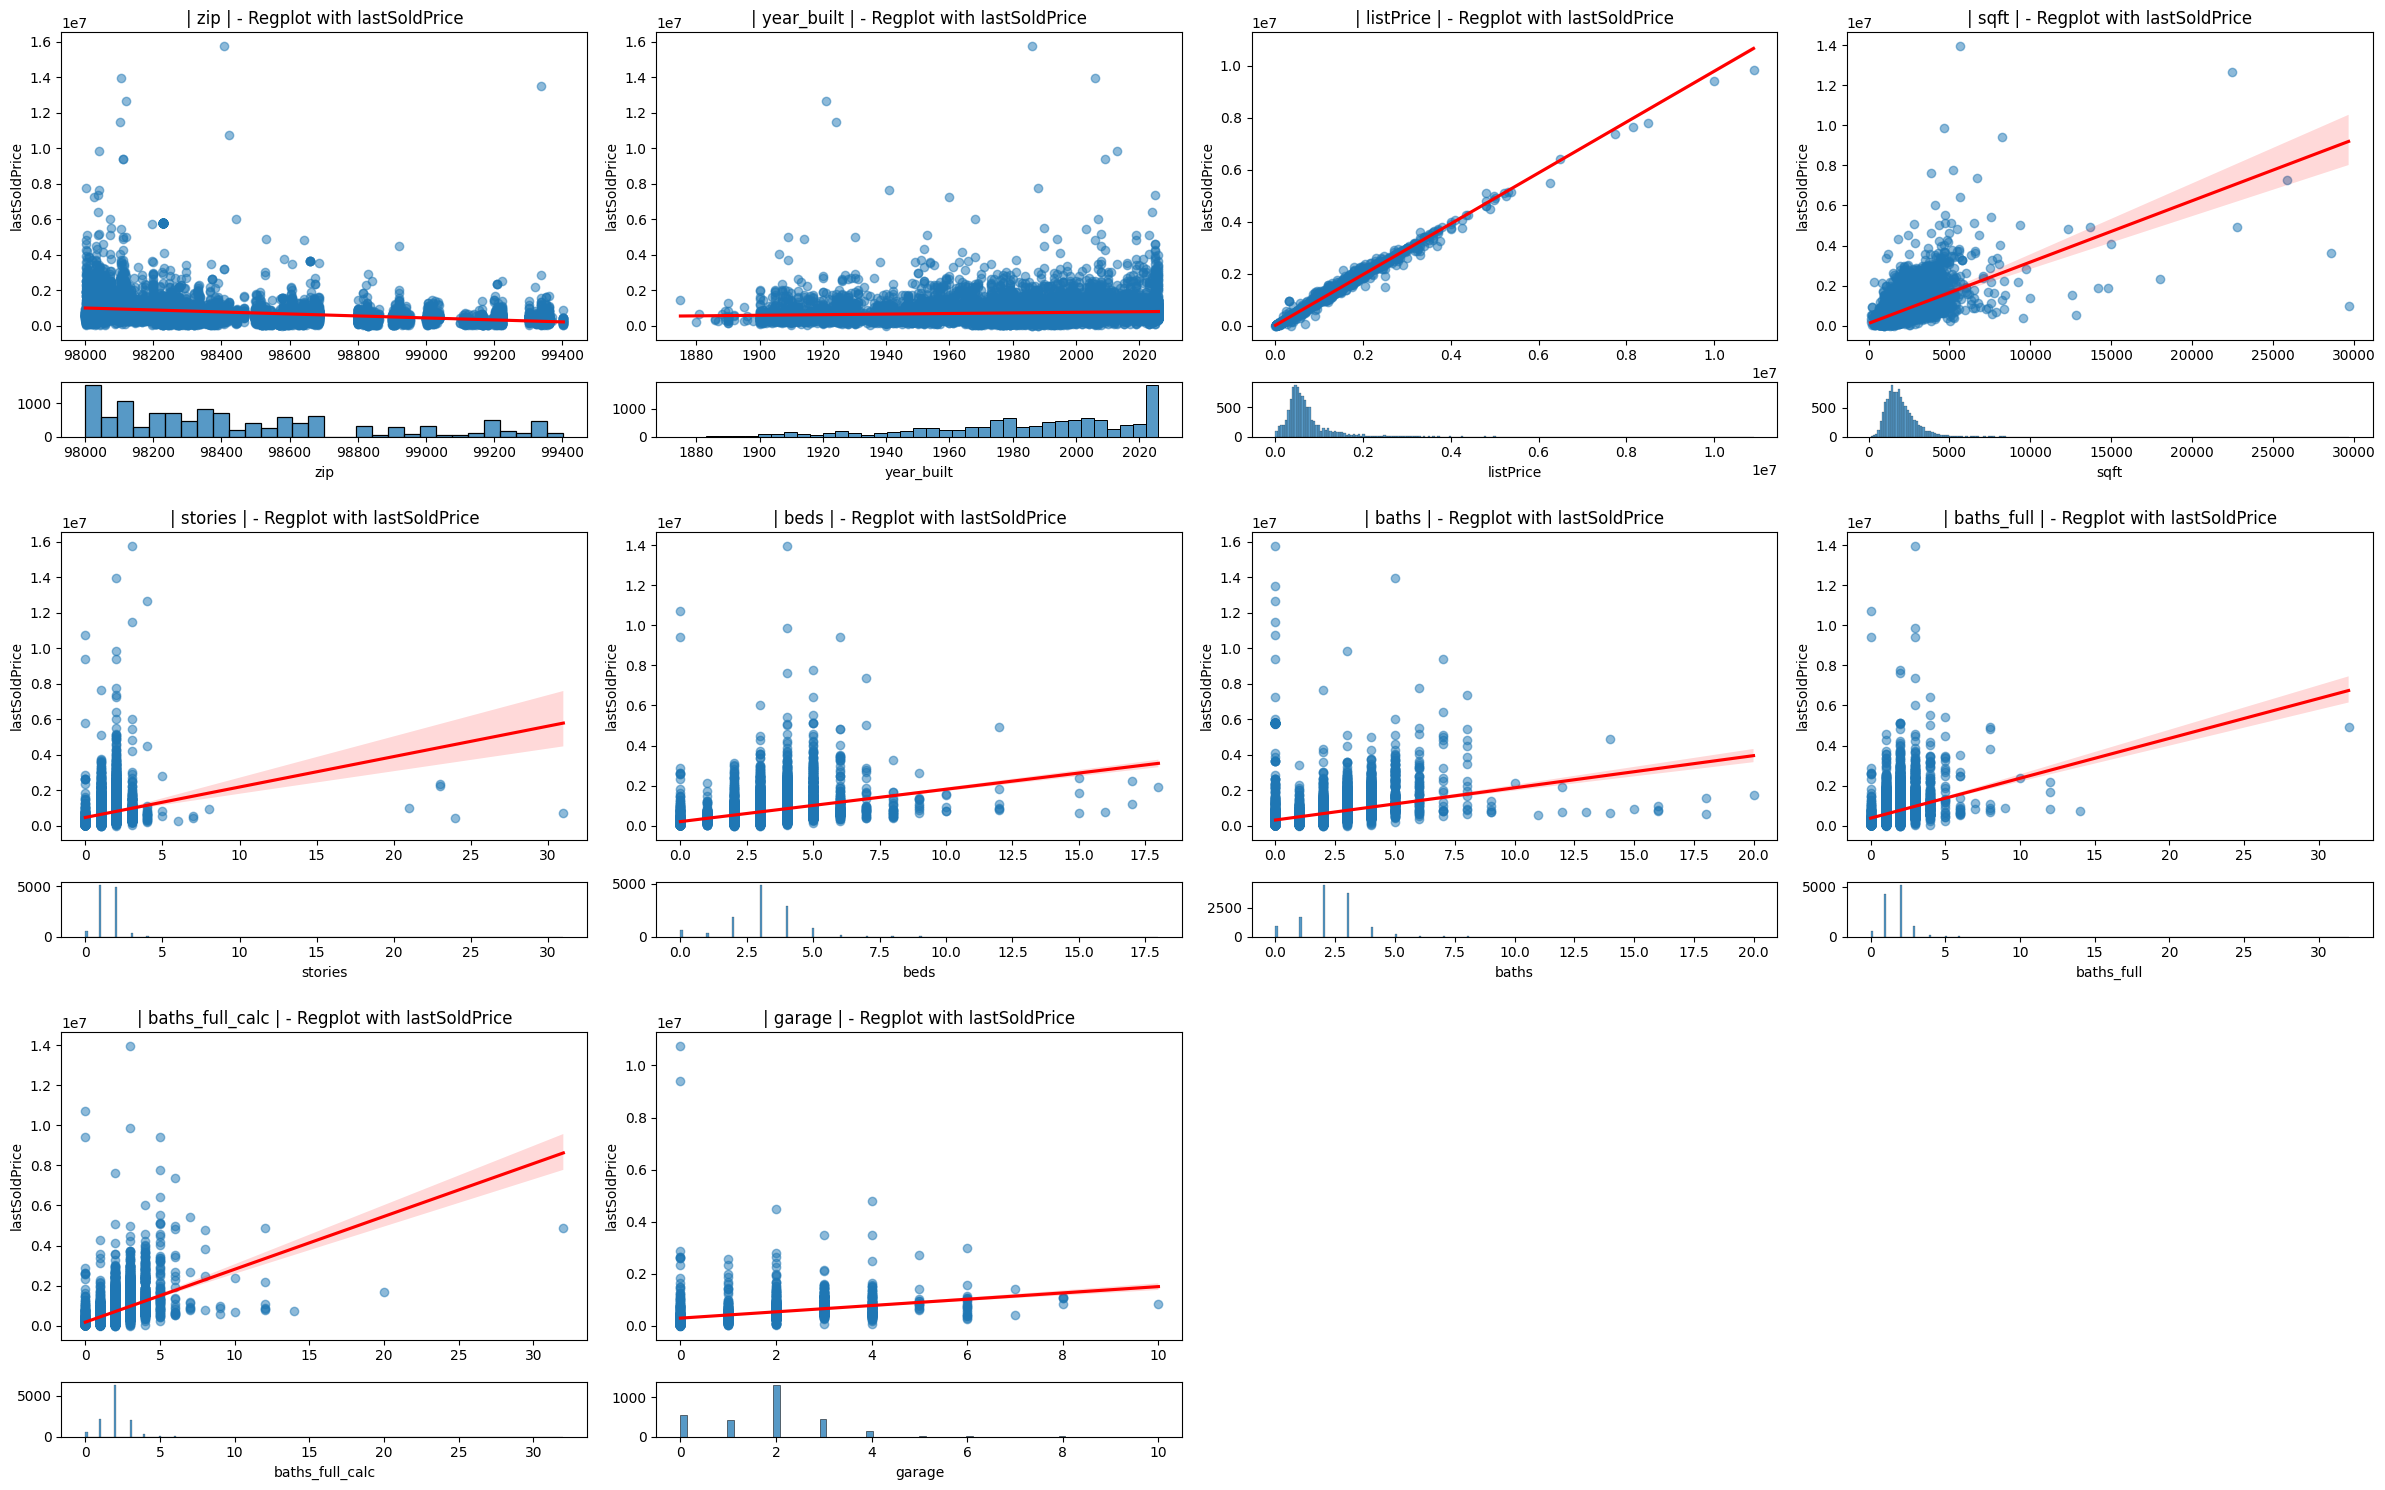

In [189]:
regplot_visualisation(df, reg_col, 'lastSoldPrice')

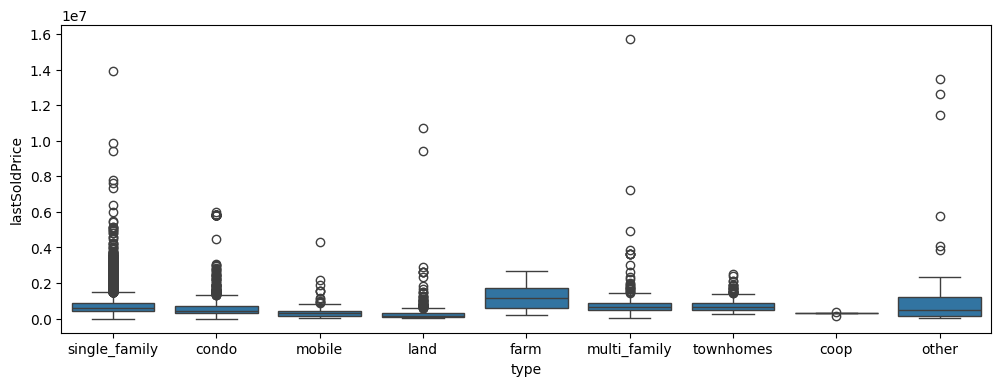

In [190]:
plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='type', y='lastSoldPrice')
plt.show()

# Variable "sanitized_text"

In [191]:
print('"sanitized_text" :')
print(f'Nombre de doublons : {df["sanitized_text"].duplicated().sum()}')
print(f'Ratio : {round(df["sanitized_text"].duplicated().sum() / len(df) * 100, 2)} %')

"sanitized_text" :
Nombre de doublons : 1883
Ratio : 15.67 %


Questionnement sur la pipeline pour créer le texte :
- Même Habitation vendu à différentes dates ?
- Même type de logement voir même vendeur --> description de base très similaire ?

In [192]:
# Valeur la plus fréquente
dupl_max = df['sanitized_text'].value_counts().index[0]
# Prendre les lignes avec cette valeur
df_dupl = df[df['sanitized_text'] == dupl_max]
#
print(dupl_max)
display(df_dupl)

the foyer is open to spacious great room with vaulted ceiling. kitchen includes stainless steel appliances, quality cabinets with soft close doors and drawers.


,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text,population,group_zip
443,98930.0,single_family,2025.0,401776.0,401932.0,1.0004,1530.0,262.70,1.0,3.0,1.0,1.0,1.0,2.0,the foyer is open to spacious great room with ...,15730.0,central_valleys
557,98930.0,single_family,2026.0,413536.0,413548.0,1.0000,1870.0,221.15,1.0,4.0,2.0,1.0,2.0,3.0,the foyer is open to spacious great room with ...,15730.0,central_valleys
3103,99301.0,single_family,2026.0,455587.0,455432.0,0.9997,1600.0,284.64,1.0,3.0,2.0,1.0,2.0,2.0,the foyer is open to spacious great room with ...,87044.0,spokane_inland_empire
4001,99301.0,single_family,2026.0,490218.0,490391.0,1.0004,1590.0,308.42,1.0,3.0,2.0,1.0,2.0,3.0,the foyer is open to spacious great room with ...,87044.0,spokane_inland_empire
5366,99301.0,single_family,2026.0,374181.0,374160.0,0.9999,1150.0,325.36,1.0,1.0,2.0,2.0,2.0,2.0,the foyer is open to spacious great room with ...,87044.0,spokane_inland_empire
5670,98930.0,single_family,2025.0,389782.0,389919.0,1.0004,1590.0,245.23,1.0,3.0,1.0,1.0,1.0,2.0,the foyer is open to spacious great room with ...,15730.0,central_valleys
8373,99301.0,single_family,2025.0,588741.0,558718.0,0.9490,1670.0,334.56,1.0,3.0,2.0,2.0,2.0,3.0,the foyer is open to spacious great room with ...,87044.0,spokane_inland_empire
10704,99301.0,single_family,2025.0,484257.0,484259.0,1.0000,1870.0,258.96,1.0,4.0,2.0,1.0,2.0,3.0,the foyer is open to spacious great room with ...,87044.0,spokane_inland_empire


In [193]:
# Valeur la plus fréquente
dupl_max = df['sanitized_text'].value_counts().index[20]
# Prendre les lignes avec cette valeur
df_dupl = df[df['sanitized_text'] == dupl_max]
#
print(dupl_max)
display(df_dupl)

the Bennett at Ivy Terrace is designed for modern living. the open main floor invites you in with a bright kitchen, dining, and living space ideal for hosting, relaxing, and everyday life.


,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text,population,group_zip
3168,98087.0,townhomes,2026.0,615086.0,615066.0,1.0000,1440.0,427.13,2.0,2.0,3.0,1.0,2.0,NaN,the Bennett at Ivy Terrace is designed for mod...,41796.0,puget_sound_core
3542,98087.0,townhomes,2026.0,614941.0,615063.0,1.0002,1440.0,427.13,2.0,2.0,3.0,1.0,2.0,NaN,the Bennett at Ivy Terrace is designed for mod...,41796.0,puget_sound_core
8642,98087.0,townhomes,2026.0,615091.0,615067.0,1.0000,1440.0,427.13,2.0,2.0,3.0,1.0,2.0,NaN,the Bennett at Ivy Terrace is designed for mod...,41796.0,puget_sound_core


Pour le moment, je ne prend pas les mots / groupe de mot les plus fréquent dans mon analyse.

In [194]:
df['Length_text'] = df['sanitized_text'].str.len()

In [195]:
def word_count(review):
    if isinstance(review, str):
        return len(review.split())
    return np.nan

df['Word_count_text'] = df['sanitized_text'].apply(word_count)

In [196]:
df['mean_word_length_text'] = df['sanitized_text'].map(
    lambda rev: np.mean([len(word) for word in rev.split()]) if isinstance(rev, str) else np.nan
)

In [197]:
df['mean_sent_length_text'] = df['sanitized_text'].map(
    lambda rev: np.mean([len(sent) for sent in tokenize.sent_tokenize(rev)]) if isinstance(rev, str) else np.nan
    )

In [198]:
text_col = ['Length_text', 'Word_count_text', 'mean_word_length_text', 'mean_sent_length_text']

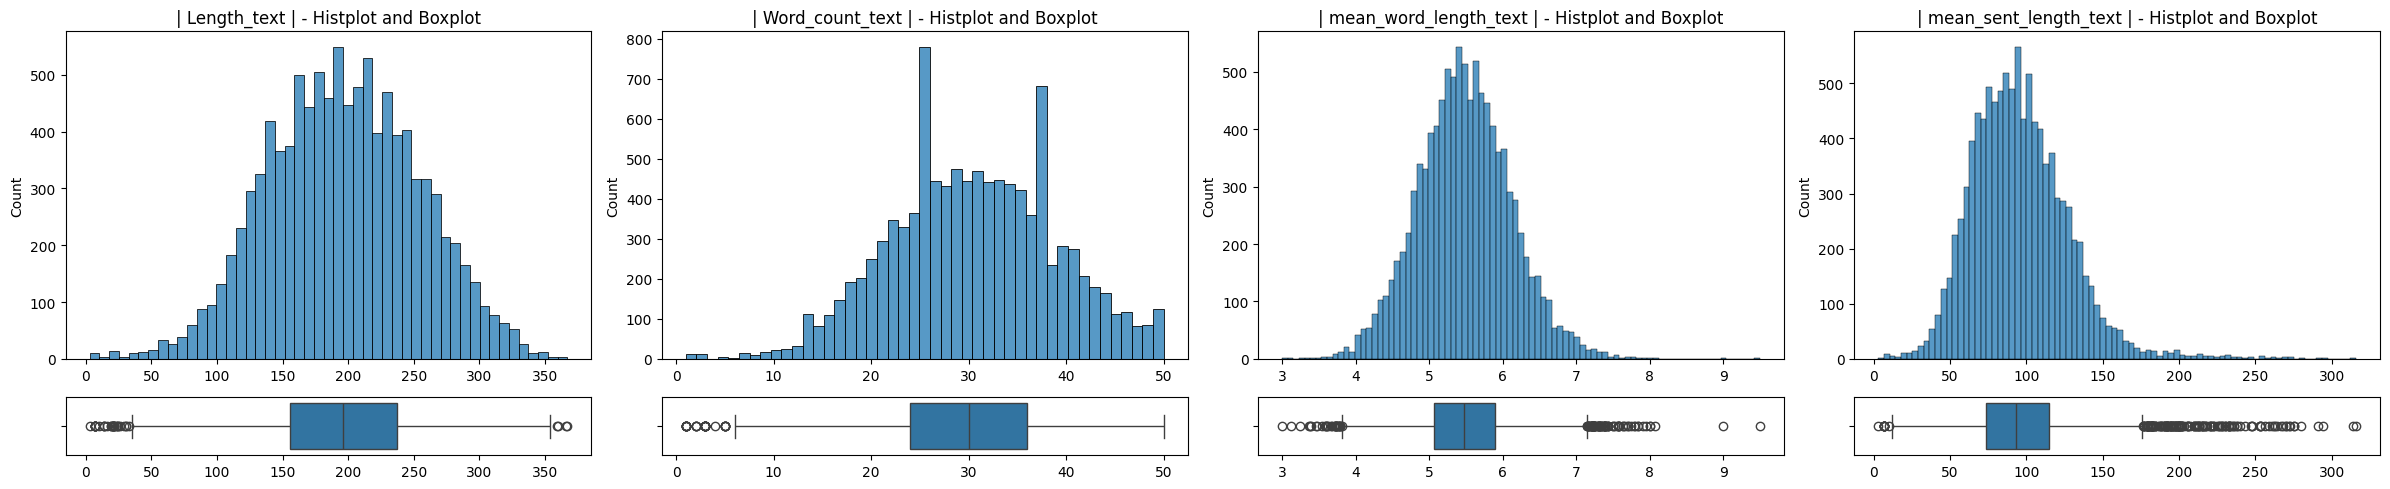

In [199]:
proportion_visualisation(df, text_col)

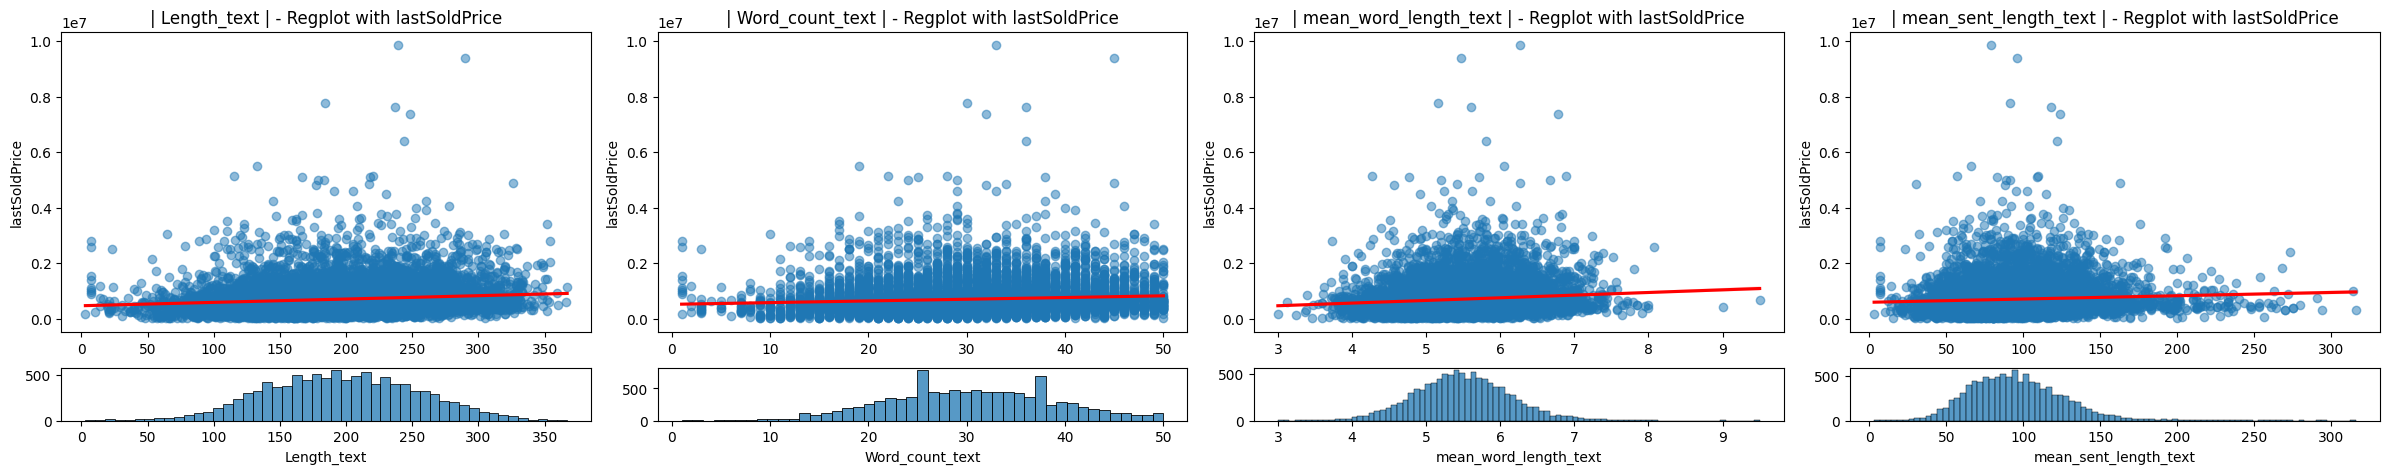

In [200]:
regplot_visualisation(df, text_col, 'lastSoldPrice')

# Pairplot

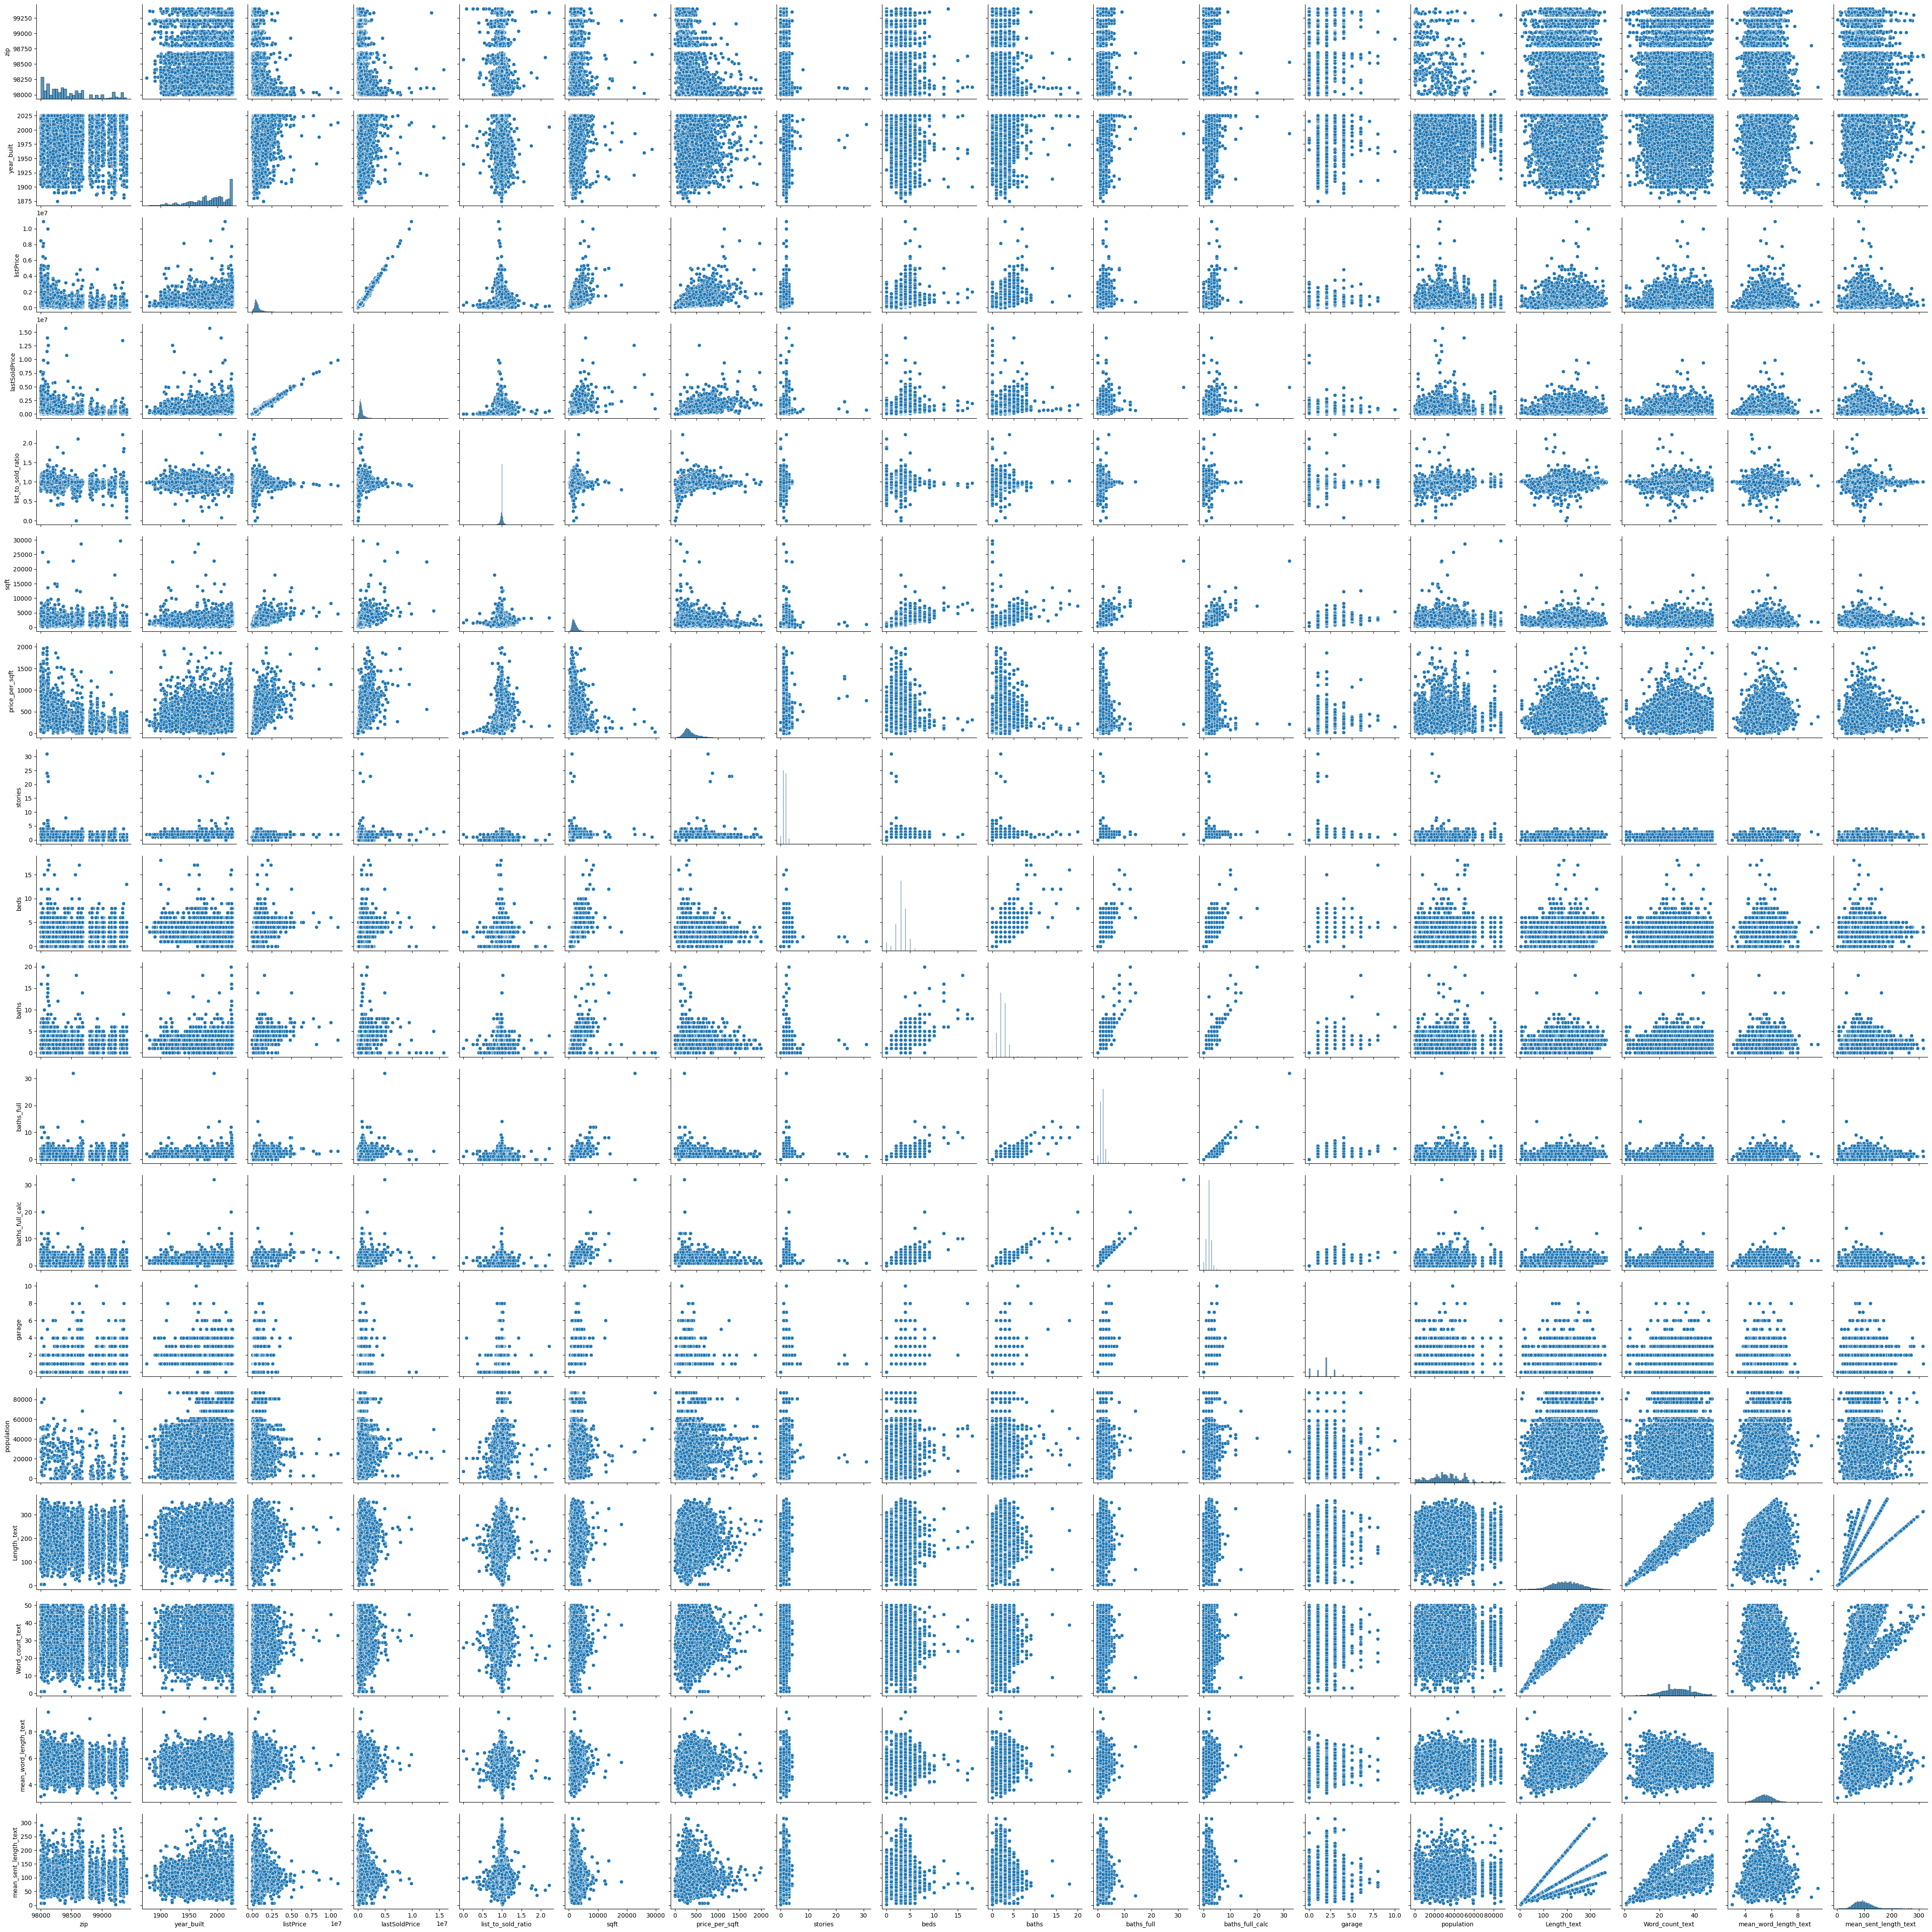

In [201]:
sns.pairplot(df)
plt.show()

# Matrice de corrélation

In [202]:
def corr_matrix(df, col, corr_method):
    # Compute the correlation matrix
    corr = df[col].corr(method=corr_method)

    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Correlation graph
    plt.figure(figsize=(12, 6))

    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, cbar=False)
    plt.title(f'{corr_method} correlation')

    plt.show()

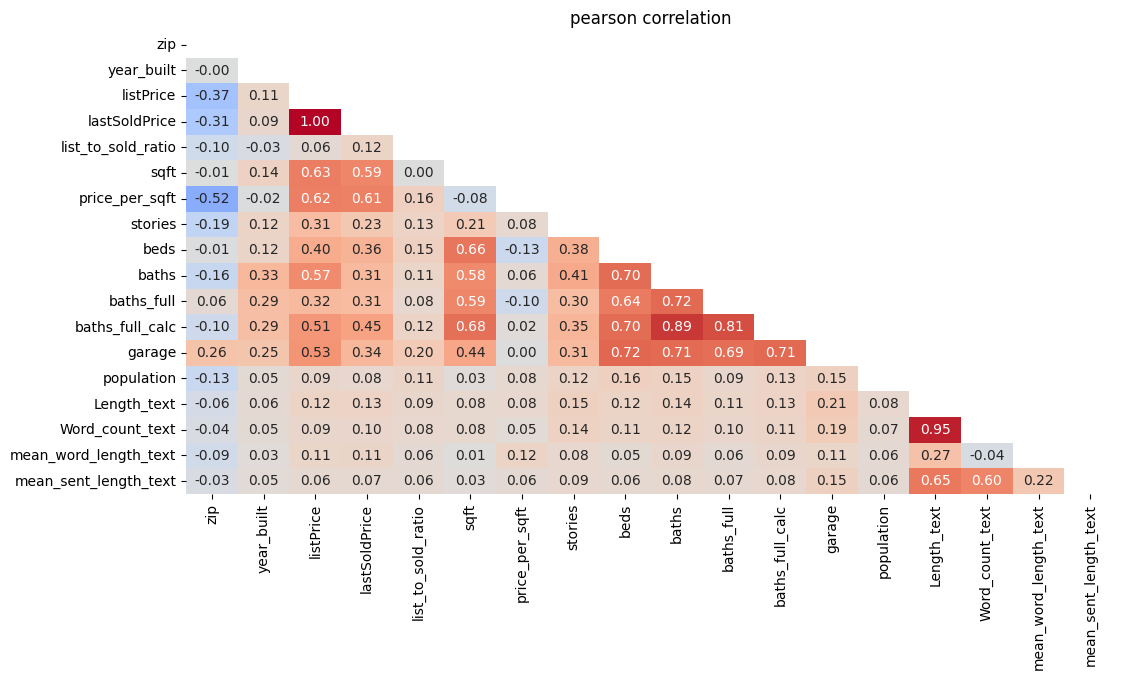

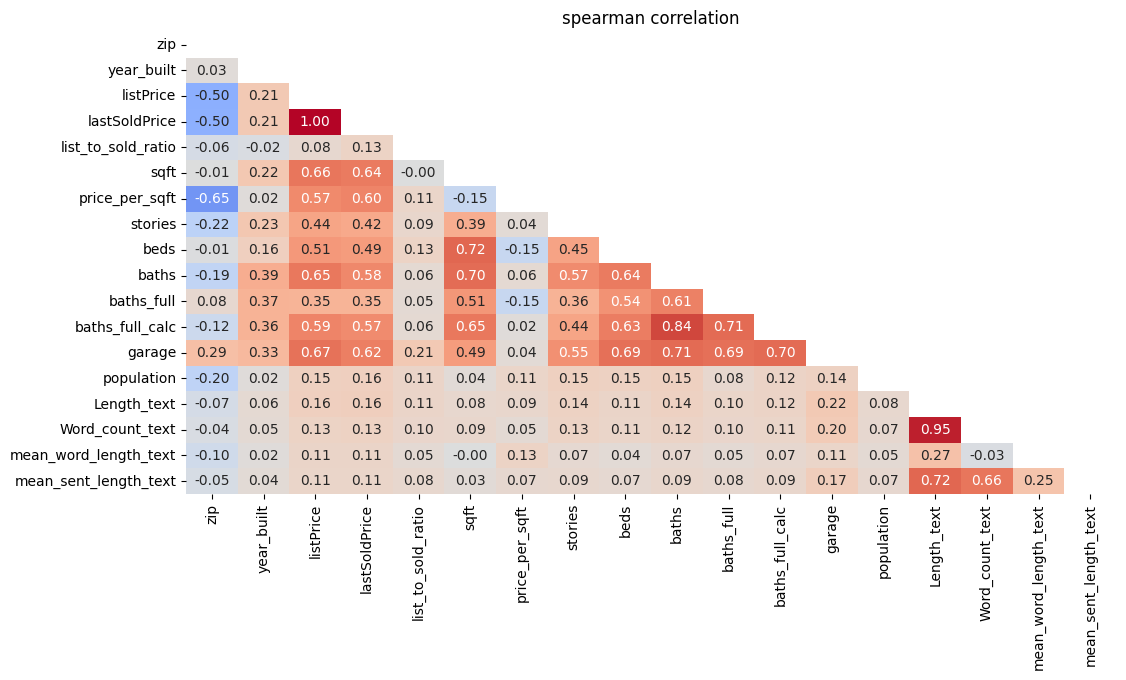

In [203]:
corr_col = df.select_dtypes(['int', 'float']).columns

corr_matrix(df, corr_col, 'pearson')
corr_matrix(df, corr_col, 'spearman')

# Modèle de test

In [204]:
df = data_raw.copy()

In [205]:
df = df.dropna(subset=['lastSoldPrice'])

In [206]:
df = df.drop(columns=['list_to_sold_ratio', 'price_per_sqft'])

In [ ]:
def fillna_incr_error(df, to_fill_col):
    mask_land = df['type'] == 'land'
    #
    for col in to_fill_col:
        df.loc[mask_land, col] = df.loc[mask_land, col].fillna(0)

    return df

def fillna_by_group_median(df, group_col, to_fill_col):
    for col in to_fill_col:
        median_val = df.groupby(group_col)[col].transform('median')
        # Remplir NaN en fonction de son groupe
        df[col] = df[col].fillna(median_val)
        # Sécurité si un groupe n'a que des NaN
        global_median = df[col].median()
        df[col] = df[col].fillna(global_median)
    
    return df

def fillna_mode(df, to_fill_col):
    for col in to_fill_col:
        modes = df[col].mode()[0]
        df[col] = df[col].fillna(modes)
    
    return df


fill_error_col = ['stories', 'beds', 'garage', 'baths', 'baths_full', 'baths_full_calc']
fill_median_col = ['year_built', 'listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage']
fill_mode_col = ['zip']

df = fillna_incr_error(df, fill_error_col)
df = fillna_by_group_median(df, 'type', fill_median_col)
df = fillna_mode(df, fill_mode_col)

In [208]:
loc_data = pd.read_csv('uszips.csv')
#
loc_data = loc_data[['zip', 'population']]

In [209]:
df = pd.merge(
    df, 
    loc_data, 
    on='zip', 
    how='left', 
)

In [210]:
def cat_zip(row):
    zip_code = str(row['zip'])
    #
    #  Mégalopole urbaine et technologique
    if zip_code.startswith(('980', '981', '982')):
        return 'puget_sound_core'
    # Zones portuaires, capitale d'état, et côte Pacifique
    elif zip_code.startswith(('983', '985', '986')):
        return 'south_and_coast'
    # Vallées agricoles et viticoles
    elif zip_code.startswith(('988', '989')):
        return 'central_valleys'
    # Seconde métropole de l'état
    elif zip_code.startswith(('990', '992', '993')):
        return 'spokane_inland_empire'
    # Autres zones peu peuplées
    elif zip_code.startswith(('98', '99')) :
        return 'other'

In [211]:
df['group_zip'] = df.apply(cat_zip, axis=1)

# 98206 --> Everett, WA = 114 000 pop
mask = df['zip'] == 98206.0
df.loc[mask, 'population'] = df.loc[mask, 'population'].fillna(114000.0)

In [212]:
def word_count(review):
    if isinstance(review, str):
        return len(review.split())
    return 0 

In [213]:
df['length_text'] = df['sanitized_text'].str.len()
df['length_text'] = df['length_text'].fillna(0)

df['word_count_text'] = df['sanitized_text'].apply(word_count)

df['mean_word_length_text'] = df['sanitized_text'].map(
    lambda rev: np.mean([len(word) for word in rev.split()]) if isinstance(rev, str) else 0
)

df['mean_sent_length_text'] = df['sanitized_text'].map(
    lambda rev: np.mean([len(sent) for sent in tokenize.sent_tokenize(rev)]) if isinstance(rev, str) else 0
    )

In [214]:
df = df.drop(columns=['sanitized_text', 'baths_full_calc'])

In [215]:
from sklearn.preprocessing import RobustScaler

scale_col = ['zip', 'year_built', 'listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'garage',
             'population', 'length_text', 'word_count_text', 'mean_word_length_text', 'mean_sent_length_text']

robust_scaler = RobustScaler()
df[scale_col] = robust_scaler.fit_transform(df[scale_col])

In [216]:
from sklearn.preprocessing import OneHotEncoder

one_hot_col = ['type', 'group_zip']

encoder_one_hot = OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=0.02, sparse_output=False)
encoded_data = encoder_one_hot.fit_transform(df[one_hot_col])
encoded_df = pd.DataFrame(encoded_data, columns=encoder_one_hot.get_feature_names_out(one_hot_col), index=df.index)
df = pd.concat([df, encoded_df], axis=1).drop(one_hot_col, axis=1)

In [217]:
from sklearn.model_selection import train_test_split

target = 'lastSoldPrice'

X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) 

In [218]:
from sklearn.model_selection import learning_curve, cross_validate, KFold

In [219]:
def model_evaluation(X_train, y_train, pipe, cv):
    cv_scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'MAE': 'neg_mean_absolute_error',
            'RMSE': 'neg_root_mean_squared_error',
            'R2': 'r2',
            'MedianAE': 'neg_median_absolute_error'
        },
        return_train_score=False,
        n_jobs=-1
    )

    return cv_scores

In [220]:
def model_learning_curve(X_train, y_train, pipe, cv):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring='neg_mean_absolute_error',
        train_sizes=np.linspace(0.1, 1.0, 10),
    )

    return train_sizes, train_scores, val_scores


def learning_curve_plot(lc_data):
    n_models = len(lc_data)
    cols = 3
    rows = int(np.ceil(n_models / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = axes.flatten()

    for ax, data in zip(axes, lc_data):

        size = data['t_size']
        tscore = data['t_score']
        vscore = data['v_score']

        train_scores_mean = -tscore.mean(axis=1)
        val_scores_mean = -vscore.mean(axis=1)

        ax.plot(size, train_scores_mean, marker='o', label='Train MAE')
        ax.plot(size, val_scores_mean, marker='o', label='Validation MAE')

        ax.set_title(data['model'])
        ax.grid(True)

        ax.legend()

    plt.tight_layout()
    plt.show()

In [221]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [222]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)

In [223]:
models = {
    'Dummy regressor': DummyRegressor(strategy='mean'),
    'linear_regression': LinearRegression(),
    'random_forest': RandomForestRegressor(random_state=0),
}

In [224]:
results = []

for model_name, model in models.items():
    cv_scores = model_evaluation(X_train, y_train, model, cv)

    results.append({
    'model': model_name,
    'MAE_mean': -cv_scores['test_MAE'].mean(),
    'RMSE_mean': -cv_scores['test_RMSE'].mean(),
    'R2_mean': cv_scores['test_R2'].mean(),
    })

results_df = pd.DataFrame(results).sort_values('MAE_mean').reset_index(drop=True)
print(results_df)

               model       MAE_mean      RMSE_mean   R2_mean
0      random_forest   73737.263225  353849.468320  0.743995
1  linear_regression  164797.503580  478035.980743  0.540643
2    Dummy regressor  389006.099241  702031.380414 -0.000552


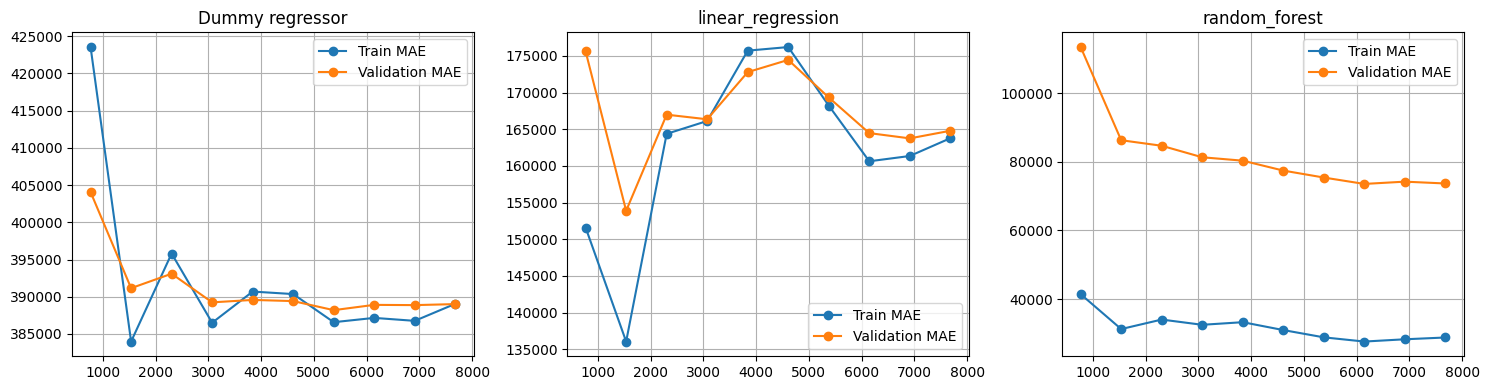

In [225]:
lc_data = []

for model_name, model in models.items():
    train_sizes, train_scores, val_scores = model_learning_curve(X_train, y_train, model, cv)

    lc_data.append({
        'model': model_name,
        't_size': train_sizes,
        't_score': train_scores,
        'v_score': val_scores
    })

learning_curve_plot(lc_data)